In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('../')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinSolver
import fcc
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import ray
# from tqdm import tqdm
import psutil
import numpy as np
from time import time
import json

In [4]:
num_workers = psutil.cpu_count(logical=False)
print(f"Number of workers: {num_workers}")
ray.init(
    num_cpus=num_workers,
    ignore_reinit_error=True,
    log_to_driver=False,
    runtime_env={
        "py_modules": [fcc],
    },
)

Number of workers: 16


2025-05-27 15:23:14,150	INFO worker.py:1762 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2025-05-27 15:23:14,160	INFO packaging.py:530 -- Creating a file package for local directory '/home/hakan-doga/data/protein-folding-qc/notebooks/../fcc'.
2025-05-27 15:23:14,167	INFO packaging.py:358 -- Pushing file package 'gcs://_ray_pkg_4c195ca6594c6c97.zip' (0.20MiB) to Ray cluster...
2025-05-27 15:23:14,169	INFO packaging.py:371 -- Successfully pushed file package 'gcs://_ray_pkg_4c195ca6594c6c97.zip'.


Python version:,3.11.12
Ray version:,2.31.0
Dashboard:,http://127.0.0.1:8265


In [5]:
ray.shutdown()

### Basic routine

In [6]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

In [7]:
optimizer = "COBYLA"
maxiter = 100
num_batches = num_workers

In [8]:
# main_seq = "LHPGAGK" # Zika
main_seq = "KLVFAA" # 6MVZ
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.99, chunk=20)
#print("Number of qubits: ", qubit_op.num_qubits)
#print("Number of terms: ", len(qubit_op))
#print(qubit_op)

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0009641647338867188
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0009703636169433594
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0008680820465087891
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0009405612945556641
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0009624958038330078
h_op size @ k = 6: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.008892059326171875
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.02084827423095703
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.022267818450927734
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.02080702781677246
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.02132868766784668
h_op size @ k = 6: 1024
Time taken to do composition @ k = 7: 0.02058267593383789
h_op siz

Below we incorporate the sampling VQE approach, where we store all the configurations sampled during the VQE optimization. In the end, we choose the top N configurations as the final result and save them in a file.

In [ ]:
shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
ansatz.measure_all()
sampler = Sampler(default_shots=shots)

In [ ]:
protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.03 seconds
 >> Processing 217 unique bitstrings took 2.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 62 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 35 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 22 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 21 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 20 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 26 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 17 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 23 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 20 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 5 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 second

In [9]:
opt_results

{'final_cost': -21.053356643356455,
 'opt_params': [3.8844760137516885,
  6.810938314604914,
  2.4478581059126028,
  4.694454233541884,
  4.904418785285307,
  6.097319285428043,
  5.480416031188028,
  6.060381445041335,
  5.849375080112312,
  3.4122798772212763,
  5.031306827872134,
  3.4403597536207826,
  3.1548915004859572,
  6.165034949541369,
  3.817190285361093,
  2.6097885928698035,
  3.906761267834674,
  3.610826096999244],
 'cost_trajectory': [-10.22230909090885,
  -9.95349370629351,
  -14.888320279720073,
  -15.031222377622175,
  -17.05923846153828,
  -19.932857342657144,
  -17.732839860139677,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -15.658903496503145,
  -21.053356643356455,
  -21.053356643356455

In [12]:
from fcc.fcc_protein_shape import ProteinShapeDecoder

best_solution = opt_results["top_solutions"][0]
print(best_solution)
shape_decoder = ProteinShapeDecoder(protein_folding_problem.peptide, solution_bitstring=best_solution[0])
print(shape_decoder.turn_sequence)

('111111110', -21.053356643356455)
[0, 9, 3]


### Extract classical results

In [7]:
cs_dir = "../classical_search/cs_res/"
# file_name = f"{main_seq}_topobj.txt"

In [11]:
def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

In [10]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

In [16]:
print(convert_bitstring_to_turns("111111110", main_seq))
print(convert_bitstring_to_turns("100011111", main_seq))

390
x20


In [10]:
cls_file_name = "4AA_LFLF_topobj.txt"
top_cls_turns = load_top_cls_solns(cls_file_name)
len(top_cls_turns)

50

### How does different R^2 threshold affect the quality of solutions?

In [5]:
shots = 10_000
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 200
num_batches = num_workers

In [19]:
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []
top_turns_list = []

r2_thresholds = [0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_list.append(opt_results["top_solutions"][:50])
    top_turns_per_r2 = [[convert_bitstring_to_turns(soln[0], main_seq), soln[1]] for soln in opt_results["top_solutions"][:50]]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/7 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00032806396484375
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003261566162109375
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003170967102050781
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00031113624572753906
h_op size @ k = 5: 64


 14%|█▍        | 1/7 [00:03<00:19,  3.32s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00032591819763183594
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003230571746826172
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00031375885009765625
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00031495094299316406
h_op size @ k = 5: 64


 29%|██▊       | 2/7 [00:06<00:16,  3.32s/it]

...

 71%|███████▏  | 5/7 [00:17<00:06,  3.46s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0005528926849365234
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00033211708068847656
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00031828880310058594
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003190040588378906
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00031304359436035156
h_op size @ k = 6: 64


 86%|████████▌ | 6/7 [00:20<00:03,  3.20s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0005369186401367188
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003311634063720703
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00031685829162597656
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003142356872558594
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0003151893615722656
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0003170967102050781
h_op size @ k = 7: 64


100%|██████████| 7/7 [00:22<00:00,  3.27s/it]


In [14]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]
top_cls_turns

[['390', -21.91],
 ['190', -14.65],
 ['b90', -14.65],
 ['090', -14.63],
 ['490', -14.63],
 ['520', -14.54],
 ['720', -14.54],
 ['180', -14.54],
 ['a90', -7.37],
 ['590', -7.37],
 ['990', -7.37],
 ['290', -7.37],
 ['690', -7.37],
 ['120', -7.28],
 ['500', -7.26],
 ['700', -7.26],
 ['280', -7.26],
 ['900', -7.26],
 ['b00', -7.26],
 ['680', -7.26]]

In [20]:
top_bitstrings_list[-1][:20]

[('111111110', -21.77836692719248),
 ('101100110', -15.016672151378398),
 ('011111010', -14.518366927192574),
 ('011111110', -14.51836692719248),
 ('011110010', -14.518366927189566),
 ('101111110', -14.49836692719247),
 ('110011011', -14.408366927192693),
 ('110111110', -14.408366927192485),
 ('110110001', -14.408366927190944),
 ('110101011', -14.408366927190558),
 ('101000010', -14.054105306457881),
 ('001101010', -7.7566721513784405),
 ('001100110', -7.7566721513784),
 ('001010110', -7.744331550800936),
 ('111100110', -7.736672151378402),
 ('100101001', -7.646672151378571),
 ('100100110', -7.646672151378402),
 ('100010101', -7.634331550802354),
 ('111111010', -7.258366927192577),
 ('001111010', -7.238366927192577)]

In [21]:
# Top 20 solutions from VQE (R^2 = 0.999)
top_turns_list[-1][:20]

[['390', -21.77836692719248],
 ['490', -15.016672151378398],
 ['b90', -14.518366927192574],
 ['390', -14.51836692719248],
 ['190', -14.518366927189566],
 ['390', -14.49836692719247],
 ['720', -14.408366927192693],
 ['390', -14.408366927192485],
 ['180', -14.408366927190944],
 ['520', -14.408366927190558],
 ['090', -14.054105306457881],
 ['590', -7.7566721513784405],
 ['490', -7.7566721513784],
 ['690', -7.744331550800936],
 ['490', -7.736672151378402],
 ['580', -7.646672151378571],
 ['490', -7.646672151378402],
 ['680', -7.634331550802354],
 ['b90', -7.258366927192577],
 ['b90', -7.238366927192577]]

In [24]:
print(f"Ground state by classical search: {top_cls_turns[0]}")
for r2_threshold in r2_thresholds:
    print(f"R^2 threshold: {r2_threshold}")
    best_solution = top_turns_list[r2_thresholds.index(r2_threshold)][0]
    print(f"VQE best solution: {best_solution}")

Ground state by classical search: ['390', -21.91]
R^2 threshold: 0.95
VQE best solution: ['490', -18.61601398601394]
R^2 threshold: 0.96
VQE best solution: ['490', -18.61601398601394]
R^2 threshold: 0.97
VQE best solution: ['490', -18.61601398601394]
R^2 threshold: 0.98
VQE best solution: ['490', -18.61601398601394]
R^2 threshold: 0.99
VQE best solution: ['390', -21.053356643356455]
R^2 threshold: 0.995
VQE best solution: ['390', -21.053356643356455]
R^2 threshold: 0.999
VQE best solution: ['390', -21.77836692719248]


In [ ]:
main_seq = "GNLVS" # 4QXX
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []
top_turns_list = []

r2_thresholds = r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_list.append(opt_results["top_solutions"][:50])
    top_turns_per_r2 = [[convert_bitstring_to_turns(soln[0], main_seq), soln[1]] for soln in opt_results["top_solutions"][:50]]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/6 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0003681182861328125
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003540515899658203
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00034308433532714844
h_op size @ k = 4: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.003851175308227539
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.008121013641357422
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.00917506217956543
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009124040603637695
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009428977966308594
h_op size @ k = 6: 1024
Beads 1 and 4 -- dist_op size: 161
h_op size @ k = 1: 161
Time taken to do composition @ k = 2: 0.0036478042602539062
h_op size @ k = 2: 687
Time taken to do composition @ k = 3: 0.006261587142944336
h_op size @ k = 3: 800
Time

 17%|█▋        | 1/6 [00:05<00:28,  5.65s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0003170967102050781
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003180503845214844
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00031113624572753906
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003190040588378906
h_op size @ k = 5: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.004019975662231445
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.008126020431518555
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.009523868560791016
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009411096572875977
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009387016296386719
h_op size @ k = 6: 1024
Beads 1 and 4 -- dist_op size: 161
h_op size @ k = 1: 161
Time taken to do composition @ k = 2: 0.00310516357421875
h_op size @ k = 2: 687
Time 

 33%|███▎      | 2/6 [00:11<00:22,  5.52s/it]

...

 67%|██████▋   | 4/6 [00:22<00:11,  5.59s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0005249977111816406
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003561973571777344
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003859996795654297
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003681182861328125
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00038313865661621094
h_op size @ k = 6: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.003386974334716797
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.008395671844482422
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.009704113006591797
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009402036666870117
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009764909744262695
h_op size @ k = 6: 1024
Time taken to do composition @ k = 7: 0.00958704948425293
h_op

 83%|████████▎ | 5/6 [00:27<00:05,  5.64s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00032401084899902344
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.000324249267578125
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003199577331542969
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003120899200439453
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00030994415283203125
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.00031113624572753906
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.003297090530395508
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.008222103118896484
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008961200714111328
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009509086608886719
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009540081024169922
h_o

100%|██████████| 6/6 [00:33<00:00,  5.60s/it]


In [26]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]
top_cls_turns

[['6390', -14.29],
 ['9390', -14.29],
 ['4190', -13.28],
 ['5b90', -13.28],
 ['0b90', -13.04],
 ['1490', -12.73],
 ['b090', -12.49],
 ['a490', -12.49],
 ['1390', -12.19],
 ['7390', -12.19],
 ['8390', -11.95],
 ['9720', -11.95],
 ['b520', -11.95],
 ['0390', -11.95],
 ['a180', -11.71],
 ['0720', -11.71],
 ['0520', -11.71],
 ['8590', -11.48],
 ['7a90', -11.48],
 ['6190', -11.46]]

In [27]:
top_bitstrings_list[-1][:20]

[('1010110101111110', -14.020218929287793),
 ('1010110010111110', -13.962514410708472),
 ('1001111001110010', -13.40835835286217),
 ('1100110000111010', -13.156776031448427),
 ('1001111010111010', -12.445791507984953),
 ('1110110101111110', -12.440218929287795),
 ('0011110110111110', -12.318358352891902),
 ('1011110010111110', -12.14251441070847),
 ('1011101110101011', -12.078358352909843),
 ('1011100010011011', -12.078358352868467),
 ('0110110001111110', -12.06677603143821),
 ('1110101101110001', -11.826776031431006),
 ('1000111001110010', -11.58835835286217),
 ('1000110000111010', -11.576776031448428),
 ('0011111100111110', -11.355791507947428),
 ('1101110000111010', -11.336776031448426),
 ('1000110101111110', -11.190218929287795),
 ('1000110101110010', -11.177878328740547),
 ('0110110000111110', -11.16191370509655),
 ('1000110010111110', -11.13251441070847)]

In [28]:
# Top 20 solutions from VQE (R^2 = 0.999)
top_turns_list[-1][:20]

[['6390', -14.020218929287793],
 ['9390', -13.962514410708472],
 ['4190', -13.40835835286217],
 ['0b90', -13.156776031448427],
 ['5b90', -12.445791507984953],
 ['6390', -12.440218929287795],
 ['7390', -12.318358352891902],
 ['9390', -12.14251441070847],
 ['b520', -12.078358352909843],
 ['9720', -12.078358352868467],
 ['8390', -12.06677603143821],
 ['a180', -11.826776031431006],
 ['4190', -11.58835835286217],
 ['0b90', -11.576776031448428],
 ['1390', -11.355791507947428],
 ['0b90', -11.336776031448426],
 ['6390', -11.190218929287795],
 ['6190', -11.177878328740547],
 ['0390', -11.16191370509655],
 ['9390', -11.13251441070847]]

In [32]:
print(f"Ground states by classical search: {top_cls_turns[0], top_cls_turns[1]}")
for r2_threshold in r2_thresholds:
    print(f"R^2 threshold: {r2_threshold}")
    best_solution = top_turns_list[r2_thresholds.index(r2_threshold)][0], top_turns_list[r2_thresholds.index(r2_threshold)][1]
    print(f"VQE best solution: {best_solution}")

Ground states by classical search: (['6390', -14.29], ['9390', -14.29])
R^2 threshold: 0.9
VQE best solution: (['5090', -23.121891845759087], ['5090', -21.541891845759086])
R^2 threshold: 0.95
VQE best solution: (['0590', -19.522661076528102], ['9490', -18.506507230374485])
R^2 threshold: 0.98
VQE best solution: (['1490', -17.202229883455097], ['0590', -16.751987589742157])
R^2 threshold: 0.99
VQE best solution: (['1490', -14.739155200706552], ['9390', -14.57194412936533])
R^2 threshold: 0.995
VQE best solution: (['1490', -15.685446760779097], ['b520', -12.335516690886182])
R^2 threshold: 0.999
VQE best solution: (['6390', -14.020218929287793], ['9390', -13.962514410708472])


In [ ]:
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []
top_turns_list = []

r2_thresholds = r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_list.append(opt_results["top_solutions"][:50])
    top_turns_per_r2 = [[convert_bitstring_to_turns(soln[0], main_seq), soln[1]] for soln in opt_results["top_solutions"][:50]]
    top_turns_list.append(top_turns_per_r2) 

  0%|          | 0/7 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00033593177795410156
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003299713134765625
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003390312194824219
h_op size @ k = 4: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0032858848571777344
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.009552001953125
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008828163146972656
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.00924539566040039
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009077787399291992
h_op size @ k = 6: 1024
Beads 0 and 5 -- dist_op size: 411
h_op size @ k = 1: 411
Time taken to do composition @ k = 2: 0.02557682991027832
h_op size @ k = 2: 8124
Time taken to do composition @ k = 3: 0.18646502494812012
h_op size @ k = 3: 15339
Time t

 14%|█▍        | 1/7 [01:41<10:10, 101.67s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00035190582275390625
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003337860107421875
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00032210350036621094
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003199577331542969
h_op size @ k = 5: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.004225015640258789
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.009762048721313477
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.009840011596679688
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.010035037994384766
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.010332107543945312
h_op size @ k = 6: 1024
Beads 0 and 5 -- dist_op size: 411
h_op size @ k = 1: 411
Time taken to do composition @ k = 2: 0.030308961868286133
h_op size @ k = 2: 8124
Ti

 29%|██▊       | 2/7 [03:27<08:39, 103.99s/it]

...

 71%|███████▏  | 5/7 [08:56<03:38, 109.08s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0003559589385986328
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003209114074707031
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00030493736267089844
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003190040588378906
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0008389949798583984
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0003578662872314453
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0038797855377197266
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.008714914321899414
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.009805917739868164
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009935140609741211
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009467124938964844
h_o

 86%|████████▌ | 6/7 [10:43<01:48, 108.40s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00032806396484375
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003418922424316406
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003170967102050781
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003170967102050781
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0003120899200439453
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.00030303001403808594
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0034198760986328125
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.009042978286743164
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.009785890579223633
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009975671768188477
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.01007699966430664
h_op s

100%|██████████| 7/7 [12:33<00:00, 107.70s/it]


In [34]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]
top_cls_turns

[['85b20', -18.91],
 ['a7920', -18.91],
 ['36120', -18.91],
 ['34120', -18.91],
 ['41580', -18.88],
 ['39b80', -18.88],
 ['70590', -18.82],
 ['81a90', -18.82],
 ['18a90', -18.79],
 ['07120', -18.78],
 ['05120', -18.78],
 ['07590', -18.69],
 ['a9720', -18.42],
 ['8b520', -18.42],
 ['97490', -18.3],
 ['70b90', -17.98],
 ['81490', -17.98],
 ['68b90', -17.93],
 ['52780', -17.33],
 ['93b80', -17.33]]

In [35]:
top_bitstrings_list[-1][:20]

[('110100110010011100101001', -17.26374820265835),
 ('011111111000011110101011', -16.285442978450124),
 ('010101111000011110101011', -16.255442978450123),
 ('110111110011110010111001', -15.782876133081864),
 ('101111111100011100100110', -15.302053427017235),
 ('110001110010011100101001', -15.193748202658348),
 ('110001110000100110100110', -15.18216588098679),
 ('011111110000011110101011', -14.70544297845013),
 ('011111101000011110101011', -14.705442978450126),
 ('011110111000011110101011', -14.605442978450125),
 ('010111111000011110101011', -14.575442978450125),
 ('001111110000111110101001', -14.483748202778985),
 ('101111101000101001110001', -14.475608779156106),
 ('110101101000110110101001', -14.423041934244694),
 ('110101110011110010111001', -14.102876133081864),
 ('111100110011110010111001', -14.072876133081863),
 ('101011101011001101110001', -14.016321939280836),
 ('101111110000111010111001', -13.91118135787213),
 ('001101111000011110101011', -13.865442978450126),
 ('1110001010011

In [36]:
# Top 20 solutions from VQE (R^2 = 0.999)
top_turns_list[-1][:20]

[['41580', -17.26374820265835],
 ['8b520', -16.285442978450124],
 ['8b520', -16.255442978450123],
 ['39b80', -15.782876133081864],
 ['81490', -15.302053427017235],
 ['41580', -15.193748202658348],
 ['97490', -15.18216588098679],
 ['8b520', -14.70544297845013],
 ['8b520', -14.705442978450126],
 ['8b520', -14.605442978450125],
 ['8b520', -14.575442978450125],
 ['2b580', -14.483748202778985],
 ['94180', -14.475608779156106],
 ['27580', -14.423041934244694],
 ['39b80', -14.102876133081864],
 ['39b80', -14.072876133081863],
 ['1a180', -14.016321939280836],
 ['25b80', -13.91118135787213],
 ['8b520', -13.865442978450126],
 ['72520', -13.851459612795397]]

In [37]:
print(f"Ground states by classical search: {top_cls_turns[0], top_cls_turns[1], top_cls_turns[2], top_cls_turns[3]}")
for r2_threshold in r2_thresholds:
    print(f"R^2 threshold: {r2_threshold}")
    best_solution = top_turns_list[r2_thresholds.index(r2_threshold)][0], top_turns_list[r2_thresholds.index(r2_threshold)][1], top_turns_list[r2_thresholds.index(r2_threshold)][2], top_turns_list[r2_thresholds.index(r2_threshold)][3]
    print(f"VQE best solution: {best_solution}")

Ground states by classical search: (['85b20', -18.91], ['a7920', -18.91], ['36120', -18.91], ['34120', -18.91])
R^2 threshold: 0.9
VQE best solution: (['27280', -29.45563970350726], ['09490', -27.97866785444426], ['39900', -27.479417058084138], ['35090', -27.19563970350734])
R^2 threshold: 0.95
VQE best solution: (['09490', -19.77840802158338], ['09490', -18.288408021583386], ['09390', -17.808372317631584], ['90590', -17.78118276781267])
R^2 threshold: 0.98
VQE best solution: (['16b00', -17.724353298908625], ['1a700', -17.72435329890761], ['18500', -17.724353298905065], ['14900', -17.724353298903647])
R^2 threshold: 0.99
VQE best solution: (['1a180', -14.412256207663473], ['97490', -14.3795372090975], ['b1a80', -13.675271474817778], ['79280', -13.66240434195722])
R^2 threshold: 0.995
VQE best solution: (['16380', -16.869610339998246], ['16380', -15.189610339998245], ['07290', -15.180720796307261], ['18290', -15.171644612213266])
R^2 threshold: 0.998
VQE best solution: (['41580', -16.67

In [6]:
main_seq = "GSNQNNF"  # 6VHC (linear peptide)
num_aas = len(main_seq)
protein_folding_problem = build_pf(main_seq)

shots = 10_000
# Need MPS simulator: 7AAs -> 33 qubits
sampler = Sampler(
    default_shots=shots, options={"backend_options": {"method": "matrix_product_state"}}
)

num_hamiltonian_terms = []
top_bitstrings_list = []
top_turns_list = []

r2_thresholds = [0.999]
for r2_threshold in tqdm(r2_thresholds):
    # qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    # num_hamiltonian_terms.append(len(qubit_op))
    ham_dir = "fcc_hamilts"
    file_name = f"{main_seq}_{len(main_seq)}AAs_R2_{int(r2_threshold * 1000)}_1e-3.json"
    # # Save the qubit operator
    # with open(f"{ham_dir}/{file_name}", "w") as f:
    #     # Convert complex coefficients to real numbers
    #     qubit_op_real = qubit_op.copy()
    #     qubit_op_real.coeffs.dtype = np.float64
    #     sparse_op_list = qubit_op_real.to_sparse_list()
    #     num_qubits = qubit_op_real.num_qubits
    #     json.dump(
    #         {"num_qubits": num_qubits, "sparse_op_list": sparse_op_list},
    #         f,
    #     )

    # Load the qubit operator
    with open(f"{ham_dir}/{file_name}", "r") as f:
        data = json.load(f)
        num_qubits = data["num_qubits"]
        sparse_op_list = [
            (pauli, qubits, coeff)
            for pauli, qubits, coeff in data["sparse_op_list"]
        ]
    qubit_op = SparsePauliOp.from_sparse_list(sparse_op_list, num_qubits=num_qubits)
    print("Hamiltonian loaded.")

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=2).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(
        optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True
    )
    top_bitstrings_list.append(opt_results["top_solutions"][:50])
    top_turns_per_r2 = [[convert_bitstring_to_turns(soln[0], main_seq), soln[1]] for soln in opt_results["top_solutions"][:50]]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/1 [00:00<?, ?it/s]

Hamiltonian loaded.
 >> Sampler job took 0.20 seconds
 >> Processing 9994 unique bitstrings took 11.75 seconds
 >> Sampler job took 0.20 seconds
 >> Processing 9981 unique bitstrings took 7.34 seconds
 >> Sampler job took 0.20 seconds
 >> Processing 9976 unique bitstrings took 7.93 seconds
 >> Sampler job took 0.19 seconds
 >> Processing 9969 unique bitstrings took 8.05 seconds
 >> Sampler job took 0.21 seconds
 >> Processing 9934 unique bitstrings took 8.14 seconds
 >> Sampler job took 0.19 seconds
 >> Processing 9949 unique bitstrings took 8.24 seconds
 >> Sampler job took 0.21 seconds
 >> Processing 9918 unique bitstrings took 8.09 seconds
 >> Sampler job took 0.18 seconds
 >> Processing 9934 unique bitstrings took 8.05 seconds
 >> Sampler job took 0.20 seconds
 >> Processing 9869 unique bitstrings took 8.06 seconds
 >> Sampler job took 0.19 seconds
 >> Processing 9910 unique bitstrings took 7.91 seconds
 >> Sampler job took 0.19 seconds
 >> Processing 9916 unique bitstrings took 8.

  0%|          | 0/1 [24:58<?, ?it/s]


NameError: name 'convert_bitstring_to_turns' is not defined

In [12]:
top_turns_per_r2 = [[convert_bitstring_to_turns(soln[0], main_seq), soln[1]] for soln in opt_results["top_solutions"][:50]]
top_turns_list.append(top_turns_per_r2)

In [13]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]
top_cls_turns

[['687590', -24.97],
 ['4a7590', -24.94],
 ['0b3590', -24.94],
 ['075b20', -24.91],
 ['071a90', -24.91],
 ['057920', -24.91],
 ['a79b80', -24.78],
 ['b58a90', -24.78],
 ['143a90', -24.78],
 ['361b80', -24.78],
 ['687590', -24.97],
 ['4a7590', -24.94],
 ['0b3590', -24.94],
 ['075b20', -24.91],
 ['071a90', -24.91],
 ['057920', -24.91],
 ['a79b80', -24.78],
 ['b58a90', -24.78],
 ['143a90', -24.78],
 ['361b80', -24.78]]

In [15]:
# Top 20 solutions from VQE (R^2 = 0.999)
top_turns_list[0][:20]

[['572b90', -75.53184526651661],
 ['572b90', -75.40208605365623],
 ['572b90', -75.25370391032641],
 ['572b90', -75.18937652924086],
 ['572b90', -75.1269787335528],
 ['572b90', -75.09764332908223],
 ['572b90', -75.09139224836508],
 ['572b90', -75.06158410792479],
 ['572b90', -75.02617848804302],
 ['572b90', -75.02464889579714],
 ['572b90', -74.9950158095732],
 ['572b90', -74.98999556039047],
 ['572b90', -74.9791305830156],
 ['572b90', -74.96841920247965],
 ['572b90', -74.96445538465781],
 ['572b90', -74.95981214602457],
 ['572b90', -74.95771721667502],
 ['572b90', -74.92736847869328],
 ['572b90', -74.91954405286243],
 ['572b90', -74.90552684901658]]

In [18]:
top_bitstrings_list[0][:20]

[('001011101110011101001100011111010', -75.53184526651661),
 ('011010101110101101001100011111010', -75.40208605365623),
 ('001010001110101101001100011111010', -75.25370391032641),
 ('001010100010010101001100011111010', -75.18937652924086),
 ('001010001110001101001100011111010', -75.1269787335528),
 ('001010100010001101001100011111010', -75.09764332908223),
 ('000011001110111101001100011111010', -75.09139224836508),
 ('001011011010011101001100011111010', -75.06158410792479),
 ('101011001110011101001100011111010', -75.02617848804302),
 ('010010111010111101001100011111010', -75.02464889579714),
 ('000011001110101101001100011111010', -74.9950158095732),
 ('010010101110001101001100011111010', -74.98999556039047),
 ('011111101110001101001100011111010', -74.9791305830156),
 ('001011110110010101001100011111010', -74.96841920247965),
 ('101011011010111101001100011111010', -74.96445538465781),
 ('101011011010110101001100011111010', -74.95981214602457),
 ('001001001110101101001100011111010', -74.

## QubitOpBuilder test

In [8]:
# main_seq = "LFLF" # 6MVZ
# main_seq = "GNLVS" # 4QXX
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.999)
print(f"Number of final h_olap terms: {len(qubit_op)}")

Highest degree of the polynomial for 0 and 3: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e-02  1.45526961e-03 -2.05160189e-05]
Number of h_olap terms: 414
Highest degree of the polynomial for 0 and 4: 10
Polynomial coefficients: [ 4.99832488e+01 -6.02757162e+01  2.79964489e+01 -6.80593446e+00
  9.81171530e-01 -8.91697182e-02  5.24256098e-03 -1.98943849e-04
  4.70209240e-06 -6.29233776e-08  3.64019540e-10]
Number of h_olap terms: 9579
Highest degree of the polynomial for 0 and 5: 12
Polynomial coefficients: [ 4.99519820e+01 -5.71877241e+01  2.49724697e+01 -5.71448277e+00
  7.84640519e-01 -6.95221168e-02  4.14026698e-03 -1.69025082e-04
  4.74015109e-06 -8.97477398e-08  1.09585694e-09 -7.78864271e-12
  2.44741161e-14]
Number of h_olap terms: 180823
Highest degree of the polynomial for 1 and 4: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e

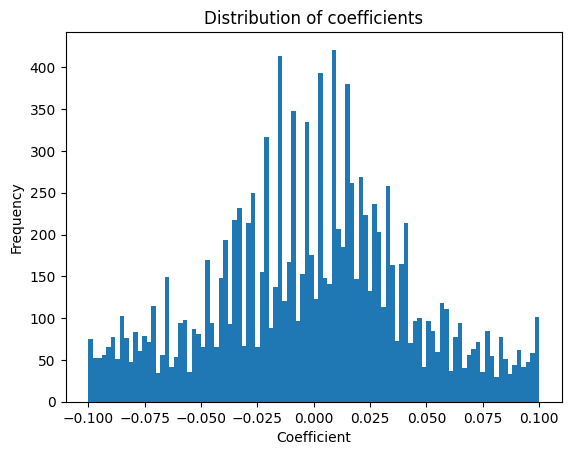

In [24]:
# Plot the distribution of the coefficients
coefficients = np.real(qubit_op.coeffs[1:])
plt.hist(coefficients, bins=100, range=(-0.1, 0.1))
plt.xlabel("Coefficient")
plt.ylabel("Frequency")
plt.title("Distribution of coefficients")
plt.show()

In [16]:
# truncated_qubit_op = qubit_op.chop(0.001)
# print(f"Number of final h_olap terms (truncated): {len(truncated_qubit_op)}")

shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 500
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.42 seconds
 >> Processing 8923 unique bitstrings took 0.56 seconds
 >> Sampler job took 0.41 seconds
 >> Processing 7452 unique bitstrings took 0.41 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 6559 unique bitstrings took 0.32 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6553 unique bitstrings took 0.33 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6851 unique bitstrings took 0.35 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6661 unique bitstrings took 0.34 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 7213 unique bitstrings took 0.36 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 6182 unique bitstrings took 0.31 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6158 unique bitstrings took 0.30 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 6101 unique bitstrings took 0.42 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 5704 unique bitstrings took 0.30 seconds
 >> Sample

In [17]:
opt_results["top_solutions"]

[('011101111000011110101011', -17.965442978456487),
 ('011101111011010010011011', -17.96544297821768),
 ('011101111100011110101011', -16.47544297845649),
 ('011101111111010010011011', -16.47544297821768),
 ('011101101000011110101011', -16.38544297845649),
 ('011101110000011110101011', -16.38544297845649),
 ('011101110011010010011011', -16.385442978217682),
 ('011101101011010010011011', -16.385442978217682),
 ('011111111000011110101011', -16.285442978456487),
 ('011100111000011110101011', -16.285442978456487),
 ('011111111011010010011011', -16.28544297821768),
 ('011100111011010010011011', -16.28544297821768),
 ('010101111000011110101011', -16.255442978456486),
 ('010101111011010010011011', -16.25544297821768),
 ('011101110100011110101011', -14.89544297845649),
 ('011101110111010010011011', -14.89544297821768),
 ('011101101111010010011011', -14.895442978217678),
 ('111110110100011010111011', -14.841181357723768),
 ('011101100000011110101011', -14.80544297845649),
 ('01110110001101001001

In [18]:
for i in range(10):
    best_solution = opt_results["top_solutions"][i][0]
    print(convert_bitstring_to_turns(best_solution, main_seq))

8b520
a9720
8b520
a9720
8b520
8b520
a9720
a9720
8b520
8b520


In [31]:
# Get the top 10 solutions from classical search
main_seq = "SNQNNF" # 2OL9
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:10]
top_cls_turns

['85b20',
 'a7920',
 '36120',
 '34120',
 '41580',
 '39b80',
 '70590',
 '81a90',
 '18a90',
 '07120']

In [19]:
# main_seq = "LFLF" # 6MVZ
main_seq = "GNLVS" # 4QXX
# main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.999)
print(f"Number of final h_olap terms: {len(qubit_op)}")

Highest degree of the polynomial for 0 and 3: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e-02  1.45526961e-03 -2.05160189e-05]
Number of h_olap terms: 414
Highest degree of the polynomial for 0 and 4: 10
Polynomial coefficients: [ 4.99832488e+01 -6.02757162e+01  2.79964489e+01 -6.80593446e+00
  9.81171530e-01 -8.91697182e-02  5.24256098e-03 -1.98943849e-04
  4.70209240e-06 -6.29233776e-08  3.64019540e-10]
Number of h_olap terms: 9579
Highest degree of the polynomial for 1 and 4: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e-02  1.45526961e-03 -2.05160189e-05]
Number of h_olap terms: 14450
Number of final h_olap terms: 1533


In [20]:
shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 200
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.02 seconds
 >> Processing 4087 unique bitstrings took 0.04 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 2124 unique bitstrings took 0.02 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 1131 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 712 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 710 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 473 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 825 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 721 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 556 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 528 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 404 unique bitstrings took 0.01 seconds
 >> Sampler job to

In [23]:
opt_results["top_solutions"]

[('1010110010111110', -13.962514410708469),
 ('1001111001110010', -13.408358352862171),
 ('1011011100100110', -13.376663577043587),
 ('1100110000111010', -13.156776031448427),
 ('1001111010111010', -12.445791507984957),
 ('1011110010111110', -12.142514410708468),
 ('1011101110101011', -12.078358352909847),
 ('1011100010011011', -12.078358352868467),
 ('1101111001110010', -11.82835835286217),
 ('1101010001101010', -11.608358352892282),
 ('1000111001110010', -11.588358352862171),
 ('1000110000111010', -11.576776031448425),
 ('0011111100111110', -11.355791507947432),
 ('1000110101110010', -11.177878328740551),
 ('1000110010111110', -11.13251441070847),
 ('1000111101110010', -11.132514410695652),
 ('0111110110111110', -10.7383583528919),
 ('1000111010111010', -10.625791507984959),
 ('1001011100100110', -10.546663577043585),
 ('1111101110101011', -10.498358352909845),
 ('1111100010011011', -10.498358352868468),
 ('1101101101110011', -10.310053128716508),
 ('1101100001110011', -10.3100531287

In [24]:
for i in range(10):
    best_solution = opt_results["top_solutions"][i][0]
    print(convert_bitstring_to_turns(best_solution, main_seq))

9390
4190
1490
0b90
5b90
9390
b520
9720
4190
8590


In [30]:
# Get the top 10 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:10]
top_cls_turns

['6390',
 '9390',
 '4190',
 '5b90',
 '0b90',
 '1490',
 'b090',
 'a490',
 '1390',
 '7390']

We can try truncating the qubit operator to keep only the terms with the relatively large coefficients. How does this affect the quality of the solutions?

In [33]:
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.999)
print(f"Number of final h_olap terms: {len(qubit_op)}")

/Users/lir9/protein-folding-qc/notebooks/../fcc/fcc_qubit_op_builder.py:261: SyntaxWarning: invalid escape sequence '\l'
  """


Number of final h_olap terms: 18133


In [35]:
truncation_thresholds = [0.1, 0.01, 0.001, 0.0001]
num_hamiltonian_terms = []
top_turns_list = []

for truncation_threshold in tqdm(truncation_thresholds):
    truncated_qubit_op = qubit_op.chop(truncation_threshold)
    num_hamiltonian_terms.append(len(truncated_qubit_op))

    ansatz = RealAmplitudes(truncated_qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=truncated_qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_trunc = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_trunc = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_trunc]
    top_turns_list.append(top_turns_per_trunc)

100%|██████████| 4/4 [06:32<00:00, 98.02s/it]


In [36]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_trunc in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_trunc if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

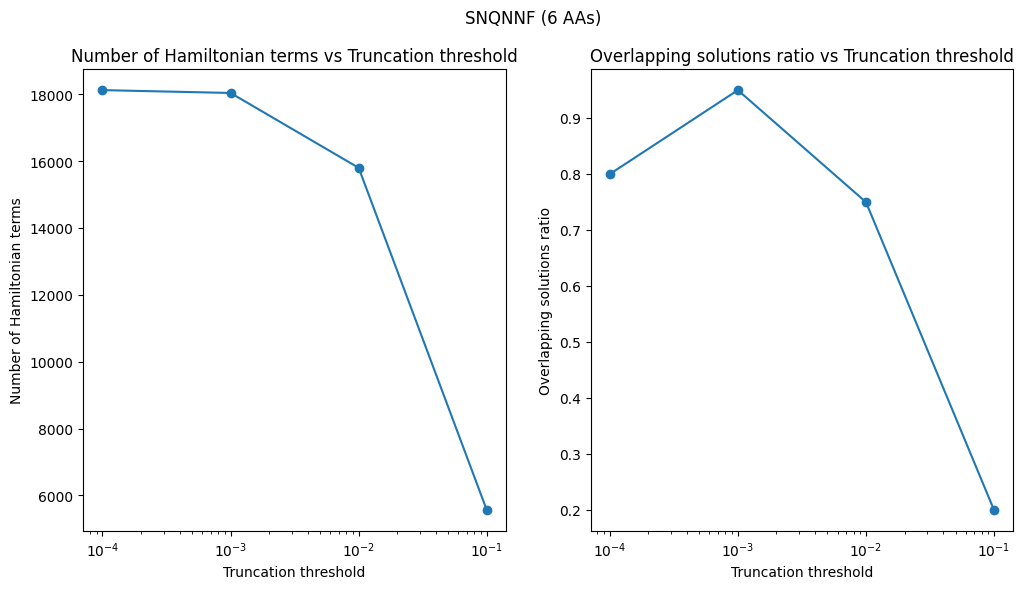

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(truncation_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xscale("log")
axs[0].set_xlabel("Truncation threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs Truncation threshold")

axs[1].plot(truncation_thresholds, overlapping_solutions_ratio, marker='o')
axs[1].set_xscale("log")
axs[1].set_xlabel("Truncation threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs Truncation threshold")

fig.suptitle("SNQNNF (6 AAs)")

plt.show()

## Invalid analysis

In [ ]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)

[0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


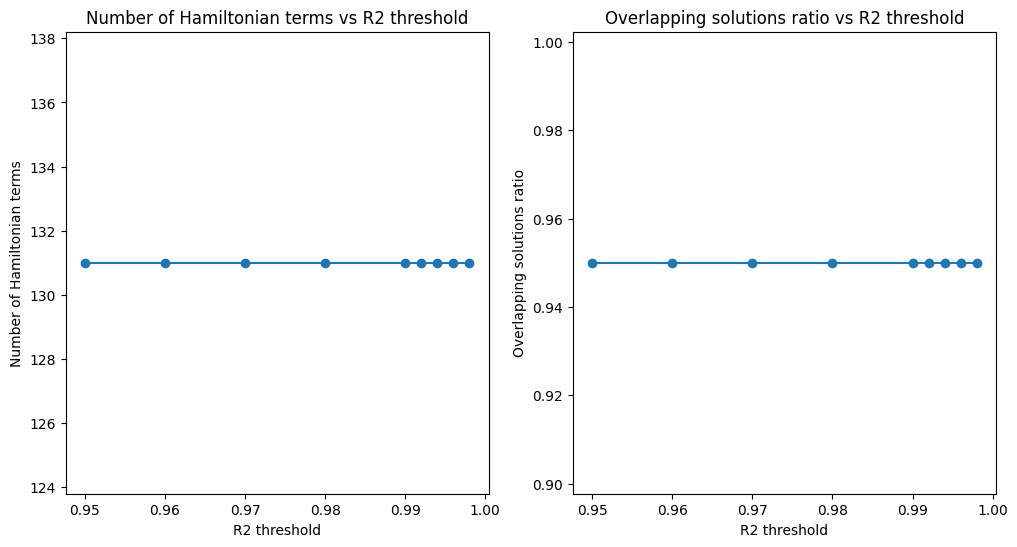

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

plt.show()